

MODEL TIME TRAVEL — FINAL REPORT

Model generations        : 8
Observations per period  : 3,500
Decision stability       : 84.28%
Decision mutation rate   : 15.72%
Evolution score          : 0.120

Most mutated feature     : previous_purchases
Most stable feature      : session_minutes

Initial ROC-AUC          : 0.807
Final ROC-AUC            : 0.787

Diagnosis                : MODERATE MODEL BEHAVIORAL EVOLUTION


MODEL PERFORMANCE


,period,accuracy,roc_auc,f1
0,Jan,0.7497,0.8070,0.7509
1,Feb,0.6994,0.7720,0.6917
2,Mar,0.7223,0.7961,0.7131
3,Apr,0.6960,0.7806,0.6871
4,May,0.7074,0.7795,0.7057
5,Jun,0.7177,0.7785,0.7158
6,Jul,0.7051,0.7792,0.7108
7,Aug,0.7086,0.7867,0.7112




FEATURE MEMORY


,feature,mean_importance,variation,memory_score
2,session_minutes,0.0714,0.0254,2.7010
6,device_score,0.0114,0.0074,1.3671
5,previous_purchases,0.0772,0.0590,1.2857
8,activity_score,0.0638,0.0558,1.1236
7,support_tickets,0.0077,0.0071,0.9492
9,price_sensitivity,0.0084,0.0131,0.5980
4,engagement,0.0084,0.0145,0.5405
0,age,0.0056,0.0118,0.4390
3,pages_viewed,0.0013,0.0024,0.3788
1,income,0.0008,0.0022,0.2371




FEATURE MUTATION


,feature,mutation_score,maximum_change
5,previous_purchases,0.0281,0.0872
8,activity_score,0.0233,0.0808
2,session_minutes,0.0211,0.0476
9,price_sensitivity,0.0174,0.0400
4,engagement,0.0111,0.0335
0,age,0.0103,0.0320
6,device_score,0.0079,0.0145
7,support_tickets,0.0051,0.0149
3,pages_viewed,0.0032,0.0072
1,income,0.0022,0.0046


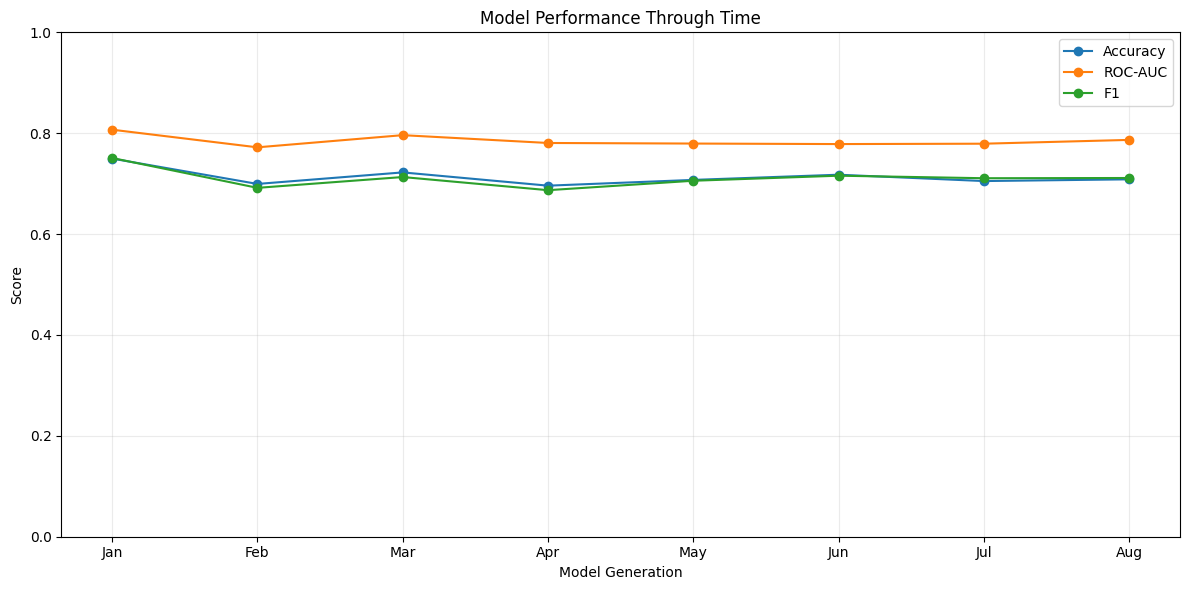

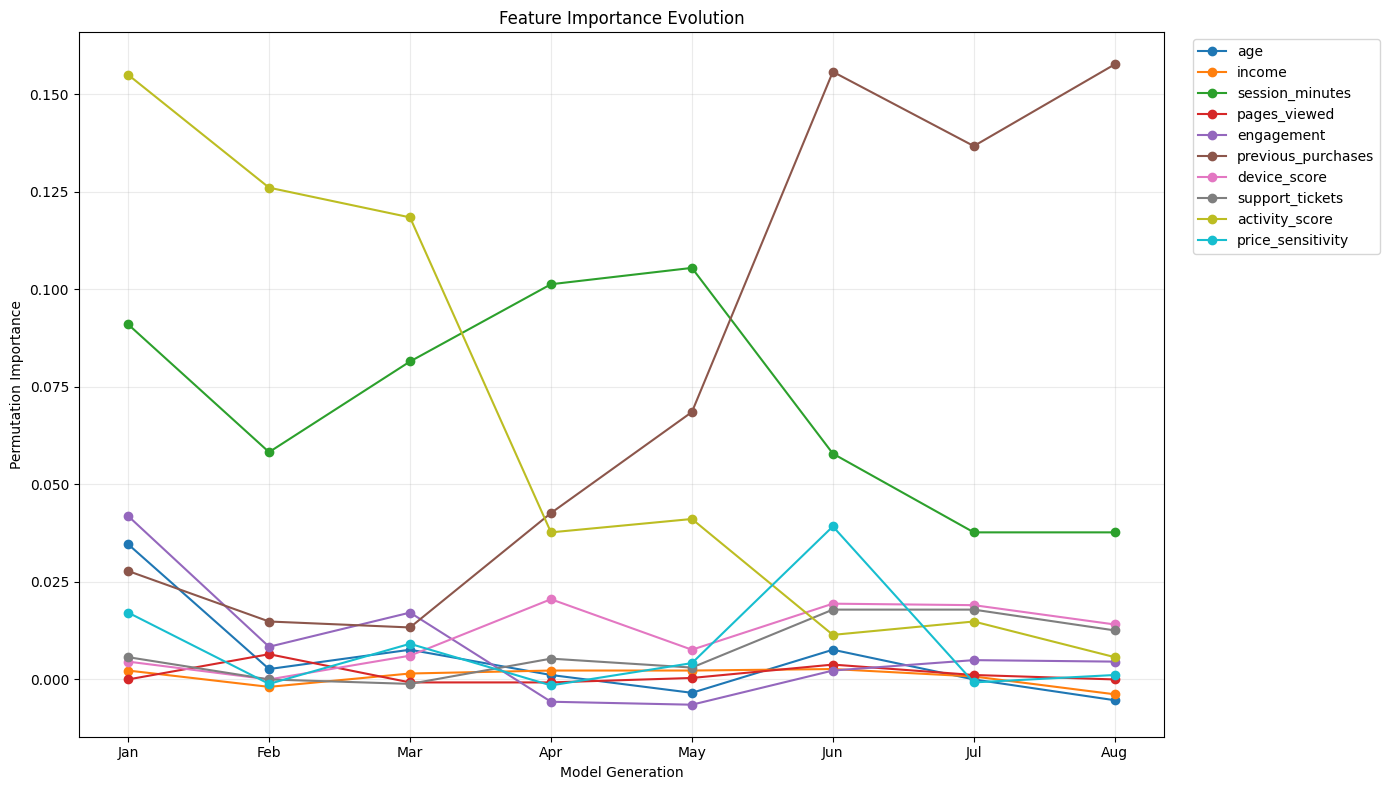

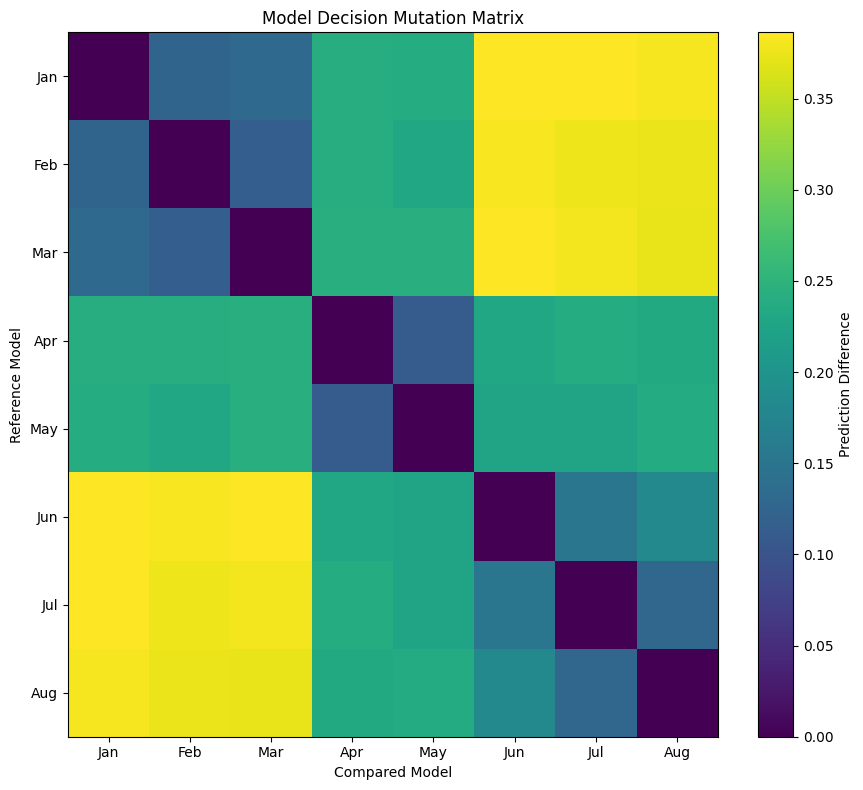

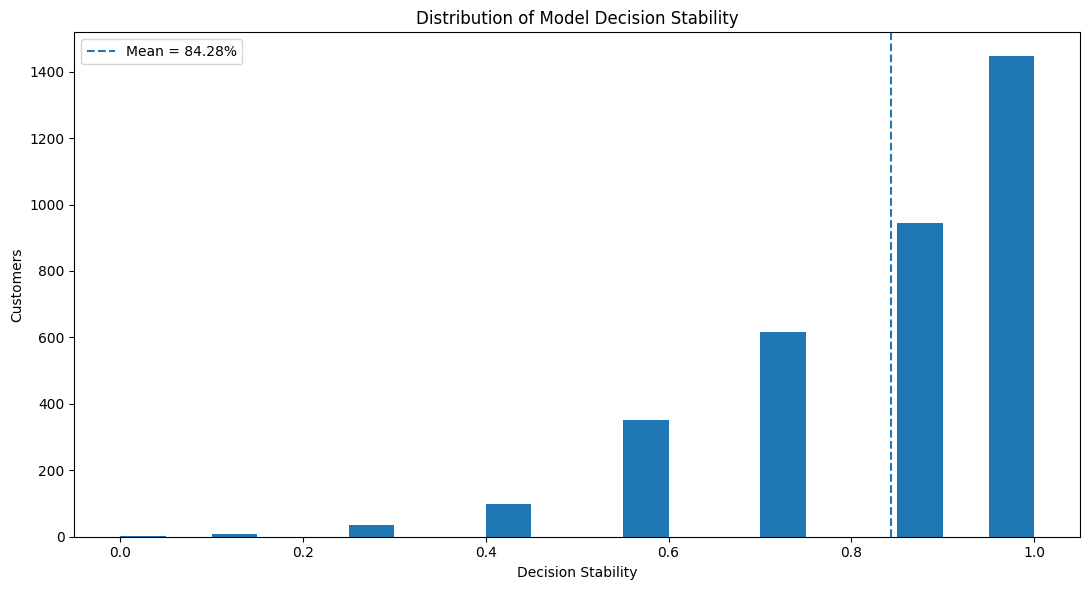

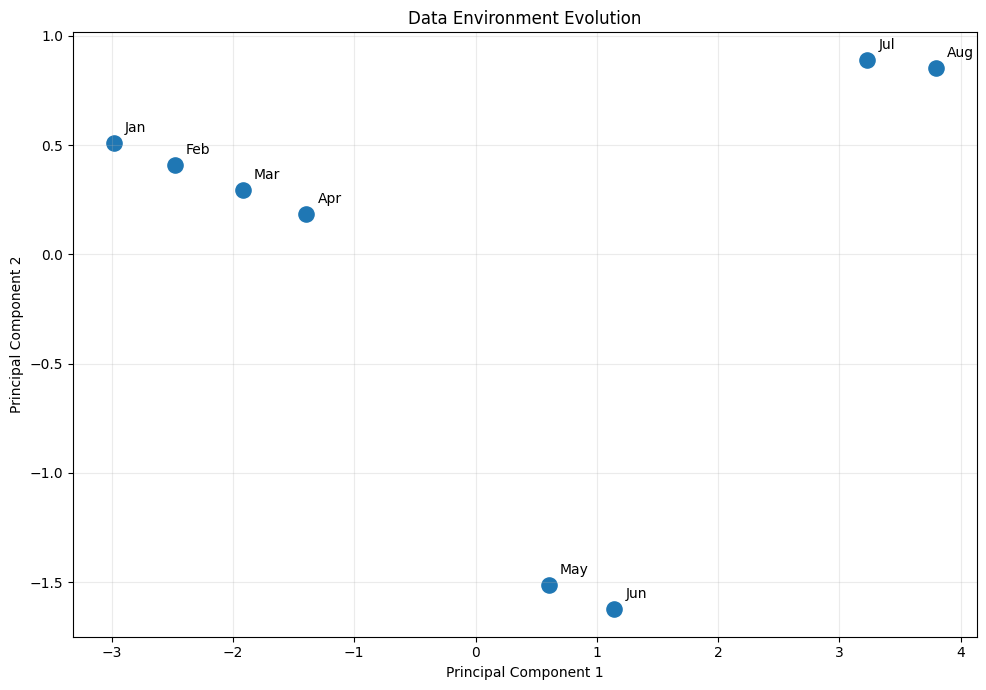

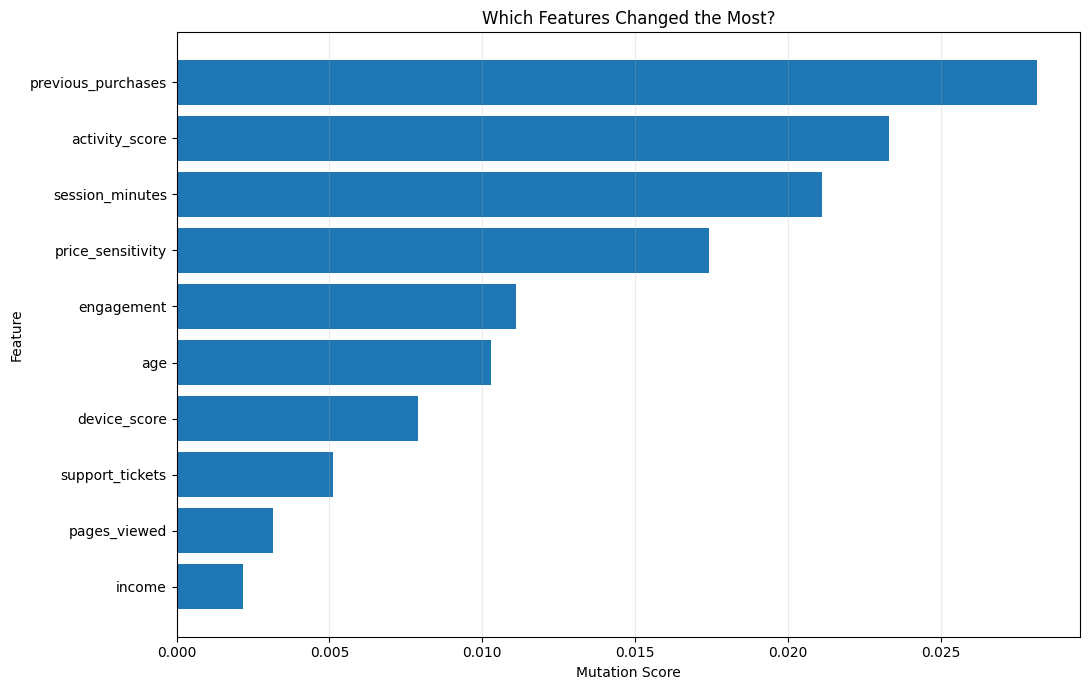

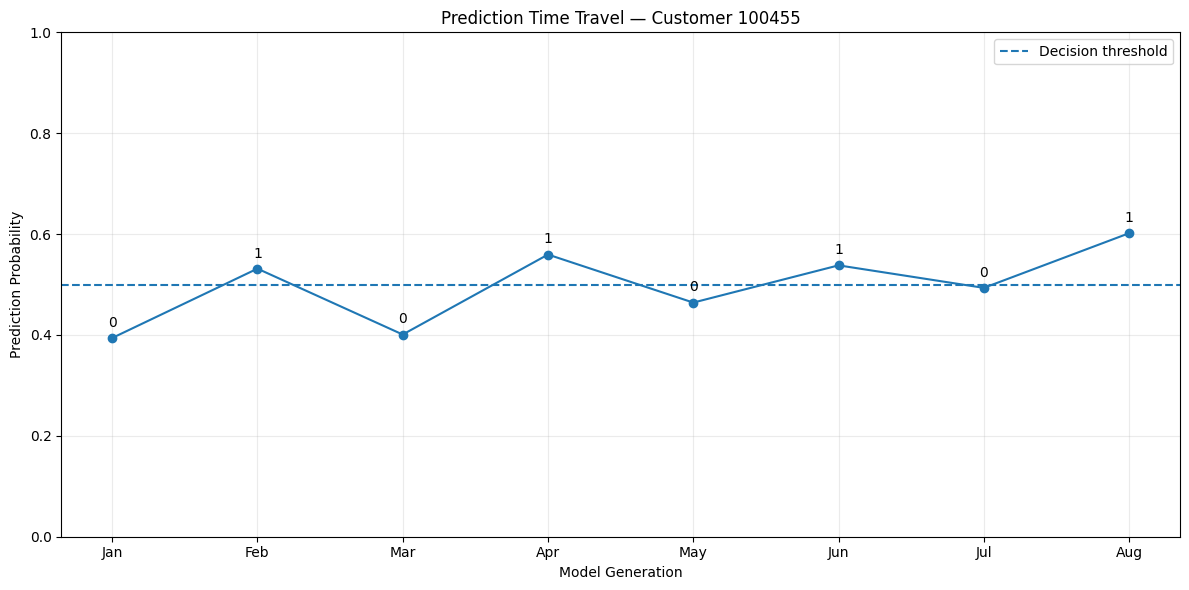



PROJECT COMPLETE

Files created:

1. model_time_travel_metrics.csv
2. model_time_travel_feature_importance.csv
3. model_time_travel_feature_memory.csv
4. model_time_travel_feature_mutations.csv
5. model_time_travel_predictions.csv

The experiment tracked:

• Model performance
• Prediction mutations
• Decision stability
• Feature importance evolution
• Feature memory
• Data distribution evolution
• Individual prediction changes



In [1]:
# ============================================================
# MODEL TIME TRAVEL — COMPLETE ONE-CELL PROJECT
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

N = 3500
PERIODS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug"]

FEATURES = [
    "age",
    "income",
    "session_minutes",
    "pages_viewed",
    "engagement",
    "previous_purchases",
    "device_score",
    "support_tickets",
    "activity_score",
    "price_sensitivity"
]

# ------------------------------------------------------------
# 1. CREATE BASE DATA
# ------------------------------------------------------------

base = pd.DataFrame({
    "age": np.clip(np.random.normal(35, 10, N), 18, 75),

    "income": np.random.lognormal(
        mean=10.6,
        sigma=0.45,
        size=N
    ),

    "session_minutes": np.random.gamma(
        3, 8, N
    ),

    "pages_viewed": np.random.poisson(
        7, N
    ),

    "engagement": np.random.beta(
        2, 5, N
    ),

    "previous_purchases": np.random.poisson(
        2, N
    ),

    "device_score": np.random.normal(
        0, 1, N
    ),

    "support_tickets": np.random.poisson(
        2, N
    ),

    "activity_score": np.clip(
        np.random.normal(50, 15, N),
        0,
        100
    ),

    "price_sensitivity": np.random.beta(
        3, 3, N
    )
})

base["customer_id"] = np.arange(
    100000,
    100000 + N
)

# ------------------------------------------------------------
# 2. CREATE EVOLVING DATA THROUGH TIME
# ------------------------------------------------------------

datasets = []

for t, period in enumerate(PERIODS):

    df = base.copy()

    # Gradual changes
    df["session_minutes"] *= (
        1 + 0.025 * t
    )

    df["engagement"] = np.clip(
        df["engagement"]
        + 0.01 * t
        + np.random.normal(0, 0.02, N),
        0,
        1
    )

    df["price_sensitivity"] = np.clip(
        df["price_sensitivity"]
        + 0.012 * t
        + np.random.normal(0, 0.02, N),
        0,
        1
    )

    # Distribution shift
    if t >= 4:

        df["income"] *= 0.92

        df["device_score"] += 0.35

    # Larger behavioral shift
    if t >= 6:

        df["previous_purchases"] += np.random.poisson(
            0.8, N
        )

        df["support_tickets"] += np.random.poisson(
            1.0, N
        )

    # Target mechanism evolves
    if t < 3:

        signal = (
            1.30 * df["engagement"]
            + 0.025 * df["session_minutes"]
            + 0.040 * df["pages_viewed"]
            + 0.030 * df["activity_score"]
            + 0.12 * df["previous_purchases"]
            - 0.018 * df["age"]
            - 0.50 * df["price_sensitivity"]
        )

    elif t < 5:

        signal = (
            0.85 * df["engagement"]
            + 0.035 * df["session_minutes"]
            + 0.025 * df["pages_viewed"]
            + 0.020 * df["activity_score"]
            + 0.25 * df["previous_purchases"]
            - 0.75 * df["price_sensitivity"]
            + 0.15 * df["device_score"]
        )

    else:

        signal = (
            0.55 * df["engagement"]
            + 0.025 * df["session_minutes"]
            + 0.015 * df["pages_viewed"]
            + 0.010 * df["activity_score"]
            + 0.50 * df["previous_purchases"]
            - 1.20 * df["price_sensitivity"]
            + 0.32 * df["device_score"]
            - 0.15 * df["support_tickets"]
        )

    signal = (
        signal - signal.mean()
    ) / (
        signal.std() + 1e-9
    )

    probability = 1 / (
        1 + np.exp(
            -1.5 * signal
        )
    )

    df["target"] = (
        np.random.random(N)
        < probability
    ).astype(int)

    df["period"] = t
    df["period_name"] = period

    datasets.append(df)

data = pd.concat(
    datasets,
    ignore_index=True
)

# ------------------------------------------------------------
# 3. TRAIN ONE MODEL PER TIME PERIOD
# ------------------------------------------------------------

models = {}
predictions = {}
probabilities = {}

metrics = []
importance_records = []

for t, period in enumerate(PERIODS):

    df = data[
        data["period"] == t
    ].copy()

    X = df[FEATURES]
    y = df["target"]

    split = int(
        0.75 * len(df)
    )

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    model = RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        min_samples_leaf=8,
        random_state=100 + t,
        n_jobs=-1,
        class_weight="balanced"
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:, 1]

    models[t] = model

    predictions[t] = pred

    probabilities[t] = prob

    metrics.append({
        "period": period,
        "accuracy": accuracy_score(
            y_test,
            pred
        ),
        "roc_auc": roc_auc_score(
            y_test,
            prob
        ),
        "f1": f1_score(
            y_test,
            pred
        )
    })

    # Permutation importance
    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=3,
        random_state=42,
        n_jobs=-1
    )

    for feature, value in zip(
        FEATURES,
        perm.importances_mean
    ):

        importance_records.append({
            "period": period,
            "feature": feature,
            "importance": value
        })

metrics_df = pd.DataFrame(
    metrics
)

importance_df = pd.DataFrame(
    importance_records
)

# ------------------------------------------------------------
# 4. FEATURE IMPORTANCE MATRIX
# ------------------------------------------------------------

importance_matrix = (
    importance_df
    .pivot(
        index="feature",
        columns="period",
        values="importance"
    )
    .fillna(0)
)

importance_matrix = (
    importance_matrix[
        PERIODS
    ]
)

# ------------------------------------------------------------
# 5. FEATURE MEMORY SCORE
# ------------------------------------------------------------

memory_rows = []

for feature in FEATURES:

    values = importance_matrix.loc[
        feature
    ].values

    mean_value = np.mean(
        values
    )

    variation = np.std(
        values
    )

    memory = (
        mean_value /
        (variation + 0.001)
    )

    memory_rows.append({
        "feature": feature,
        "mean_importance": mean_value,
        "variation": variation,
        "memory_score": memory
    })

memory_df = pd.DataFrame(
    memory_rows
).sort_values(
    "memory_score",
    ascending=False
)

# ------------------------------------------------------------
# 6. FEATURE MUTATION SCORE
# ------------------------------------------------------------

mutation_rows = []

for feature in FEATURES:

    values = importance_matrix.loc[
        feature
    ].values

    changes = np.abs(
        np.diff(values)
    )

    mutation_rows.append({
        "feature": feature,
        "mutation_score": changes.mean(),
        "maximum_change": changes.max()
    })

mutation_df = pd.DataFrame(
    mutation_rows
).sort_values(
    "mutation_score",
    ascending=False
)

# ------------------------------------------------------------
# 7. TRACK PREDICTIONS THROUGH TIME
# ------------------------------------------------------------

# Use the same customer population.
# Retrain each historical model and ask it to predict
# the same reference population.

reference = base[
    FEATURES
]

prediction_history = pd.DataFrame({
    "customer_id": base["customer_id"]
})

for t, period in enumerate(PERIODS):

    model = models[t]

    p = model.predict_proba(
        reference
    )[:, 1]

    pred = (
        p >= 0.5
    ).astype(int)

    prediction_history[
        f"prediction_{period}"
    ] = pred

    prediction_history[
        f"probability_{period}"
    ] = p

# ------------------------------------------------------------
# 8. DECISION MUTATION
# ------------------------------------------------------------

pred_cols = [
    f"prediction_{p}"
    for p in PERIODS
]

prob_cols = [
    f"probability_{p}"
    for p in PERIODS
]

pred_matrix = (
    prediction_history[
        pred_cols
    ]
)

mutation_count = (
    pred_matrix
    .diff(axis=1)
    .abs()
    .sum(axis=1)
)

prediction_history[
    "mutation_count"
] = mutation_count

prediction_history[
    "decision_stability"
] = (
    1 -
    mutation_count /
    (len(PERIODS) - 1)
)

decision_stability = (
    prediction_history[
        "decision_stability"
    ].mean()
)

# ------------------------------------------------------------
# 9. MODEL MUTATION MATRIX
# ------------------------------------------------------------

model_mutation = np.zeros(
    (
        len(PERIODS),
        len(PERIODS)
    )
)

for i in range(len(PERIODS)):

    for j in range(len(PERIODS)):

        a = prediction_history[
            f"prediction_{PERIODS[i]}"
        ]

        b = prediction_history[
            f"prediction_{PERIODS[j]}"
        ]

        model_mutation[i, j] = np.mean(
            a != b
        )

# ------------------------------------------------------------
# 10. EVOLUTION SCORE
# ------------------------------------------------------------

decision_mutation_rate = (
    1 - decision_stability
)

feature_instability = (
    mutation_df[
        "mutation_score"
    ].mean()
)

performance_change = abs(
    metrics_df[
        "roc_auc"
    ].iloc[-1]
    -
    metrics_df[
        "roc_auc"
    ].iloc[0]
)

# Normalize feature instability
normalized_feature_instability = min(
    feature_instability * 10,
    1
)

evolution_score = (
    0.45 * decision_mutation_rate
    +
    0.35 * normalized_feature_instability
    +
    0.20 * performance_change
)

# ------------------------------------------------------------
# 11. FIND MOST CHANGING FEATURES
# ------------------------------------------------------------

most_mutated = mutation_df.iloc[0]

most_stable = memory_df.iloc[0]

# ------------------------------------------------------------
# 12. PRINT FINAL REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 72)
print("MODEL TIME TRAVEL — FINAL REPORT")
print("=" * 72)

print(
    f"\nModel generations        : {len(PERIODS)}"
)

print(
    f"Observations per period  : {N:,}"
)

print(
    f"Decision stability       : {decision_stability:.2%}"
)

print(
    f"Decision mutation rate   : {decision_mutation_rate:.2%}"
)

print(
    f"Evolution score          : {evolution_score:.3f}"
)

print(
    f"\nMost mutated feature     : "
    f"{most_mutated['feature']}"
)

print(
    f"Most stable feature      : "
    f"{most_stable['feature']}"
)

print(
    f"\nInitial ROC-AUC          : "
    f"{metrics_df['roc_auc'].iloc[0]:.3f}"
)

print(
    f"Final ROC-AUC            : "
    f"{metrics_df['roc_auc'].iloc[-1]:.3f}"
)

if evolution_score >= 0.25:
    diagnosis = "HIGH MODEL BEHAVIORAL EVOLUTION"
elif evolution_score >= 0.12:
    diagnosis = "MODERATE MODEL BEHAVIORAL EVOLUTION"
else:
    diagnosis = "LOW MODEL BEHAVIORAL EVOLUTION"

print(
    f"\nDiagnosis                : {diagnosis}"
)

print("\n")
print("=" * 72)
print("MODEL PERFORMANCE")
print("=" * 72)

display(
    metrics_df.round(4)
)

print("\n")
print("=" * 72)
print("FEATURE MEMORY")
print("=" * 72)

display(
    memory_df.round(4)
)

print("\n")
print("=" * 72)
print("FEATURE MUTATION")
print("=" * 72)

display(
    mutation_df.round(4)
)

# ------------------------------------------------------------
# 13. VISUALIZATION — PERFORMANCE
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    PERIODS,
    metrics_df["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    PERIODS,
    metrics_df["roc_auc"],
    marker="o",
    label="ROC-AUC"
)

plt.plot(
    PERIODS,
    metrics_df["f1"],
    marker="o",
    label="F1"
)

plt.title(
    "Model Performance Through Time"
)

plt.xlabel(
    "Model Generation"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 14. VISUALIZATION — FEATURE EVOLUTION
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 8)
)

for feature in FEATURES:

    plt.plot(
        PERIODS,
        importance_matrix.loc[
            feature
        ],
        marker="o",
        label=feature
    )

plt.title(
    "Feature Importance Evolution"
)

plt.xlabel(
    "Model Generation"
)

plt.ylabel(
    "Permutation Importance"
)

plt.grid(
    alpha=0.25
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 15. VISUALIZATION — MODEL MUTATION MATRIX
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 8)
)

plt.imshow(
    model_mutation,
    aspect="auto"
)

plt.xticks(
    range(len(PERIODS)),
    PERIODS
)

plt.yticks(
    range(len(PERIODS)),
    PERIODS
)

plt.xlabel(
    "Compared Model"
)

plt.ylabel(
    "Reference Model"
)

plt.title(
    "Model Decision Mutation Matrix"
)

plt.colorbar(
    label="Prediction Difference"
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 16. VISUALIZATION — DECISION STABILITY
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 6)
)

plt.hist(
    prediction_history[
        "decision_stability"
    ],
    bins=20
)

plt.axvline(
    decision_stability,
    linestyle="--",
    label=(
        f"Mean = "
        f"{decision_stability:.2%}"
    )
)

plt.xlabel(
    "Decision Stability"
)

plt.ylabel(
    "Customers"
)

plt.title(
    "Distribution of Model Decision Stability"
)

plt.legend()

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 17. VISUALIZATION — DATA ENVIRONMENT EVOLUTION
# ------------------------------------------------------------

environment = []

for t in range(len(PERIODS)):

    d = data[
        data["period"] == t
    ][FEATURES]

    environment.append(
        d.mean().values
    )

environment = np.array(
    environment
)

scaled_environment = (
    StandardScaler()
    .fit_transform(environment)
)

pca = PCA(
    n_components=2
)

coords = pca.fit_transform(
    scaled_environment
)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=120
)

for i, period in enumerate(PERIODS):

    plt.annotate(
        period,
        (
            coords[i, 0],
            coords[i, 1]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "Data Environment Evolution"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 18. VISUALIZATION — FEATURE MUTATION
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 7)
)

plot_df = mutation_df.sort_values(
    "mutation_score"
)

plt.barh(
    plot_df["feature"],
    plot_df["mutation_score"]
)

plt.xlabel(
    "Mutation Score"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Which Features Changed the Most?"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 19. FIND A CUSTOMER WITH MAXIMUM DECISION MUTATIONS
# ------------------------------------------------------------

idx = (
    prediction_history[
        "mutation_count"
    ].idxmax()
)

customer = (
    prediction_history
    .loc[idx]
)

customer_id = int(
    customer["customer_id"]
)

customer_probs = [
    customer[
        f"probability_{p}"
    ]
    for p in PERIODS
]

customer_preds = [
    customer[
        f"prediction_{p}"
    ]
    for p in PERIODS
]

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    PERIODS,
    customer_probs,
    marker="o"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Decision threshold"
)

for i in range(
    len(PERIODS)
):

    plt.annotate(
        str(
            int(customer_preds[i])
        ),
        (
            PERIODS[i],
            customer_probs[i]
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.ylim(
    0,
    1
)

plt.xlabel(
    "Model Generation"
)

plt.ylabel(
    "Prediction Probability"
)

plt.title(
    f"Prediction Time Travel — Customer {customer_id}"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 20. EXPORT RESULTS
# ------------------------------------------------------------

metrics_df.to_csv(
    "model_time_travel_metrics.csv",
    index=False
)

importance_df.to_csv(
    "model_time_travel_feature_importance.csv",
    index=False
)

memory_df.to_csv(
    "model_time_travel_feature_memory.csv",
    index=False
)

mutation_df.to_csv(
    "model_time_travel_feature_mutations.csv",
    index=False
)

prediction_history.to_csv(
    "model_time_travel_predictions.csv",
    index=False
)

print("\n")
print("=" * 72)
print("PROJECT COMPLETE")
print("=" * 72)

print("""
Files created:

1. model_time_travel_metrics.csv
2. model_time_travel_feature_importance.csv
3. model_time_travel_feature_memory.csv
4. model_time_travel_feature_mutations.csv
5. model_time_travel_predictions.csv

The experiment tracked:

• Model performance
• Prediction mutations
• Decision stability
• Feature importance evolution
• Feature memory
• Data distribution evolution
• Individual prediction changes
""")